In [1]:
import torch
import matplotlib.pyplot  as plt
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv(r"output_part_1.csv")

In [3]:

print(df.shape)
cols=["Item_IDs"]+[f"Feature{i}" for i in range(1,df.shape[1])]
df.columns=cols
print(df.head())

(10000, 4097)
   Item_IDs  Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  \
0   1117355  0.567622  2.072772       0.0       0.0  0.000000  2.598417   
1   1398321  0.000000  0.000000       0.0       0.0  0.161650  0.000000   
2   1955375  0.000000  0.000000       0.0       0.0  0.071637  1.918274   
3   1955419  0.000000  0.000000       0.0       0.0  0.000000  4.186504   
4   1398711  0.000000  0.000000       0.0       0.0  0.000000  0.000000   

   Feature7  Feature8  Feature9  ...  Feature4087  Feature4088  Feature4089  \
0  0.000000  2.013906  0.202193  ...     0.000000      0.00000     0.000000   
1  0.000000  1.079505  0.000000  ...     0.000000      0.00000     1.795291   
2  0.000000  0.000000  0.195055  ...     0.169409      0.80951     4.323596   
3  0.000000  4.273407  0.000000  ...     1.777774      0.00000     0.000000   
4  1.901946  0.583513  1.633046  ...     0.000000      0.00000     0.000000   

   Feature4090  Feature4091  Feature4092  Feature4093  Featu

In [4]:
features_cols=df.columns[1:]
df[features_cols].isnull().sum()
flag=1
null_columns=[] 
for col in features_cols:
    if df[col].isnull().any():
        flag=0
        null_columns.append(col)

print("flag ", flag)
print(null_columns)
    

flag  1
[]


      Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  Feature7  \
6050 -0.374945  -0.46847 -0.444772 -0.454155 -0.613021 -0.457226  1.286960   
3415 -0.374945  -0.46847  3.532829 -0.454155 -0.613021  4.319272 -0.490188   
9486 -0.374945  -0.46847 -0.444772 -0.454155  1.121553 -0.457226 -0.490188   
4681  0.942880  -0.46847 -0.369887 -0.454155 -0.290627 -0.457226 -0.490188   
6214 -0.374945  -0.46847 -0.444772 -0.454155  0.572696 -0.457226 -0.490188   

      Feature8  Feature9  Feature10  Feature11  Feature12  Feature13  \
6050  1.091570 -0.325172   0.088841  -0.306458  -0.586752  -0.630804   
3415  0.550011  0.797488   2.023725  -0.306458  -0.586752  -0.630804   
9486 -0.490636 -0.325172  -0.607588  -0.306458  -0.586752   0.591603   
4681  1.348534 -0.325172   2.797112   1.292192  -0.586752   1.780829   
6214 -0.476514 -0.325172  -0.607588  -0.306458   1.687938   2.490922   

      Feature14  Feature15  Feature16  Feature17  Feature18  Feature19  \
6050  -0.478596  -0.3595

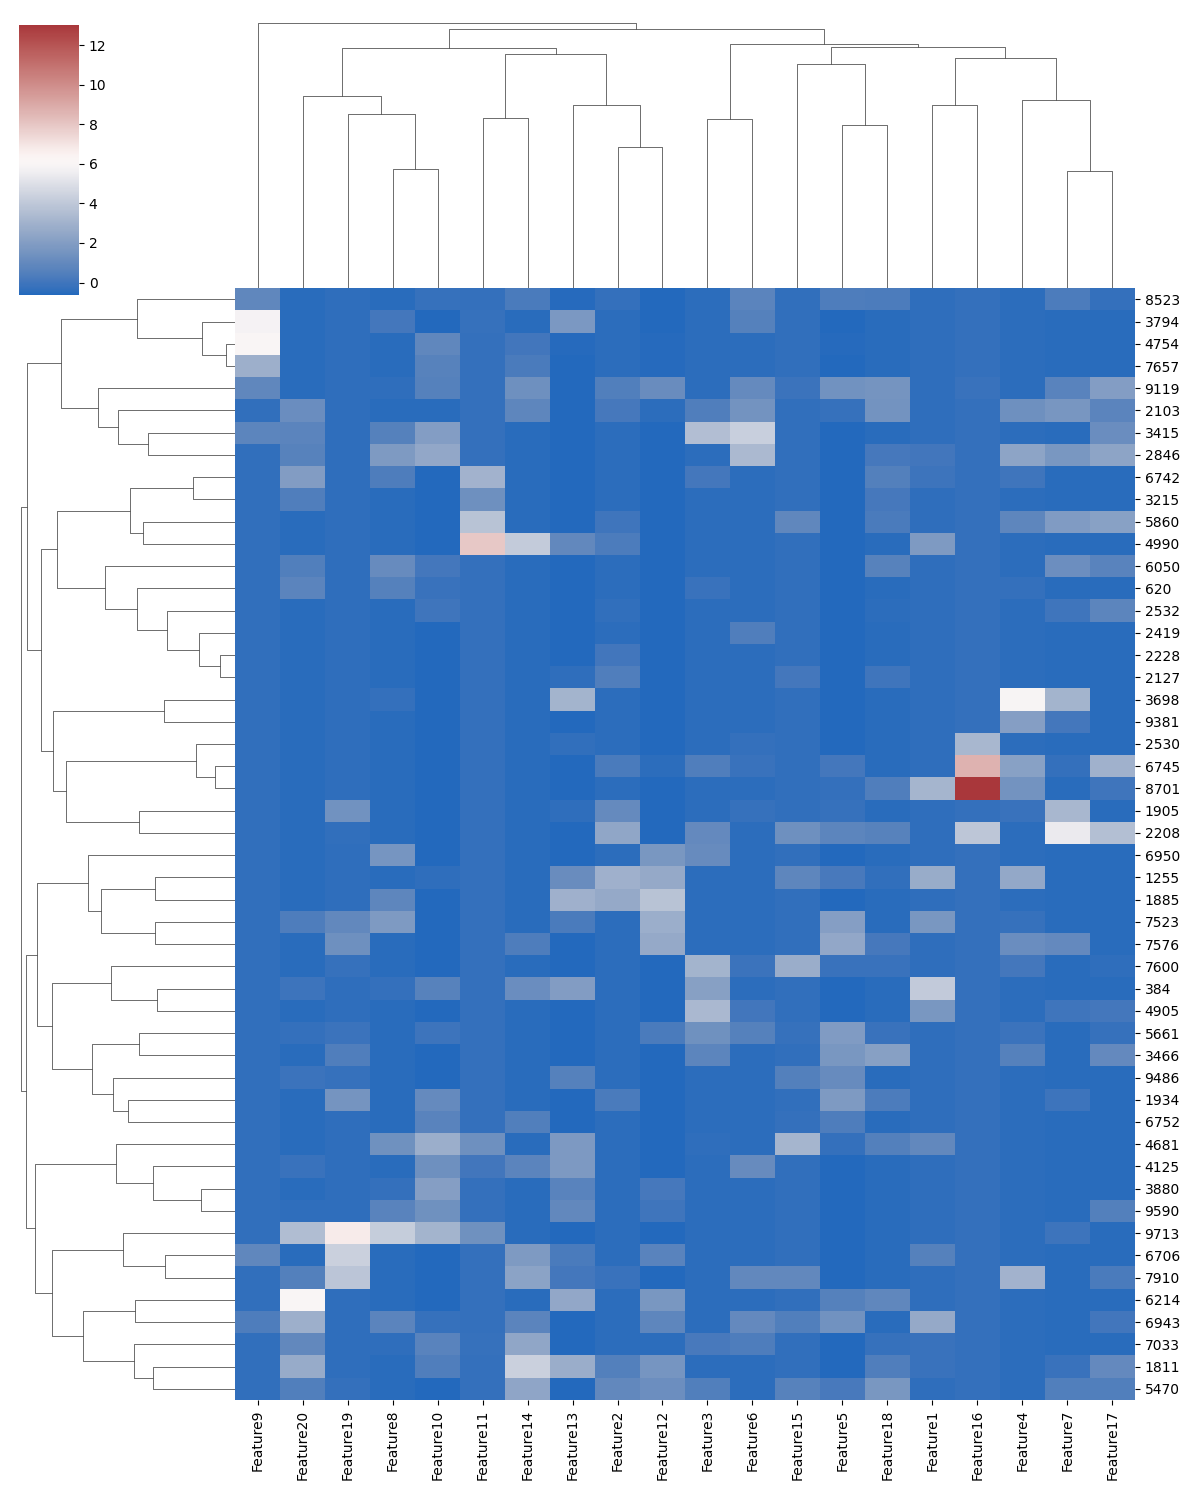

In [5]:
import seaborn as sns
#Select 20 features
#feature=df.iloc[: , 1:21]
cols=[]
for col in df.columns[1:21]:
    cols.append(col)

first_20=df[cols]  #creating a dataframe

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaled_feature=scaler.fit_transform(first_20)
scaled_df=pd.DataFrame(scaled_feature, index=first_20.index, columns=first_20.columns)
scaled_df=scaled_df.sample(50)
print(scaled_df.head())
#sns.clustermap(first_20.corr(), cmap="coolwarm", figsize=(12, 10))
#plt.show()
sns.clustermap(scaled_df, method="weighted", metric="cosine", cmap="vlag" , figsize=(12,15) , row_cluster=True, col_cluster=True,
               cbar_pos=(0.02,0.8,0.05,0.18))
plt.show()




Feature1       0.704108
Feature2       1.094939
Feature3       0.771606
Feature4       0.884994
Feature5       0.996907
                 ...   
Feature4092    0.646000
Feature4093    0.906556
Feature4094    0.914959
Feature4095    0.897652
Feature4096    1.411659
Length: 4096, dtype: float64
(4096,)
0.9125684548364851


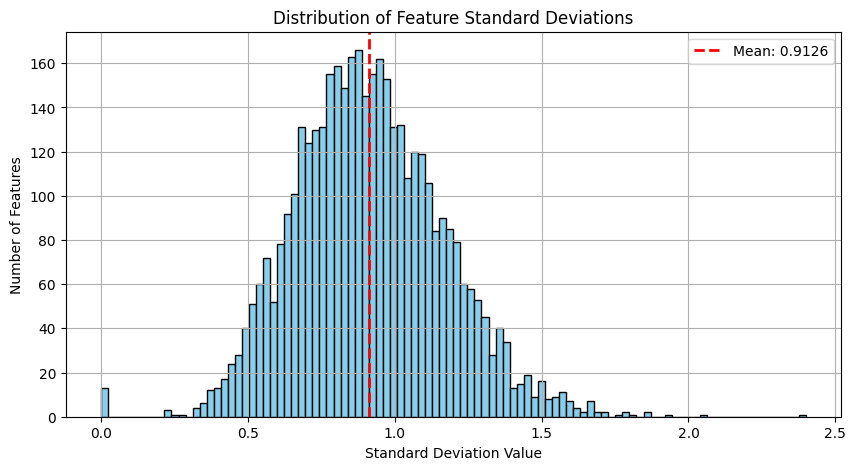

In [6]:
#features_cols = df.columns[1:]
deviations = df[features_cols].std()
print(deviations)
print(deviations.shape)
flag1=0
for cols in deviations.index:
    if(deviations[col]==0):
        print(cols, deviations[cols])
        print (flag1)
average=deviations.mean()
print(average)
import matplotlib.pyplot as plt


# 2. Plot the distribution to see where the 'mean' falls
plt.figure(figsize=(10, 5))
deviations.hist(bins=100, color='skyblue', edgecolor='black')
plt.axvline(average, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {average:.4f}')
plt.title("Distribution of Feature Standard Deviations")
plt.xlabel("Standard Deviation Value")
plt.ylabel("Number of Features")
plt.legend()
plt.show()


        


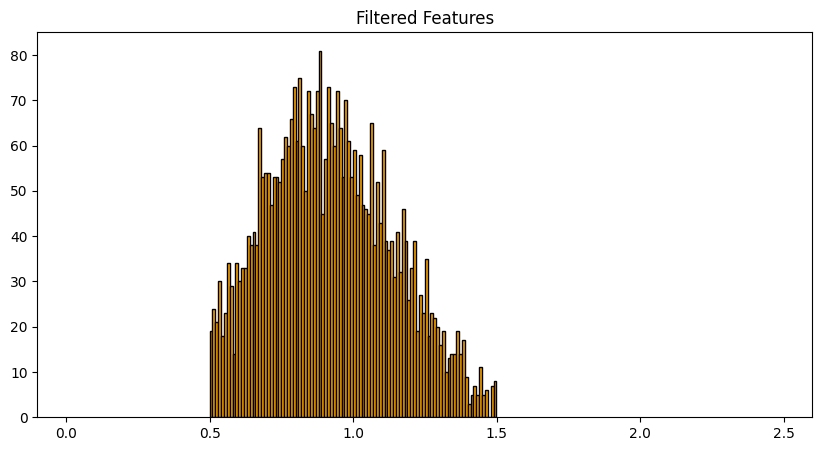

Original count: 4096
Remaining count: 3874


In [7]:


col_drop = []
for col in deviations.index:
    if (deviations[col] < 0.5) or (deviations[col] > 1.5):
        col_drop.append(col)


drop_features = deviations.drop(index=col_drop)

# Plotting the result
plt.figure(figsize=(10, 5))
plt.hist(drop_features, bins=100, color='orange', edgecolor='black')
plt.xlim(-0.1, 2.6)
plt.title("Filtered Features")
plt.show()

print(f"Original count: {len(deviations)}")
print(f"Remaining count: {len(drop_features)}")


In [8]:
df_final=df[drop_features.index]
# print(df_final.iloc[5:10])

from sklearn.decomposition import PCA
pca=PCA(n_components=0.95)
X_pca=pca.fit_transform(df_final)
df_pca=pd.DataFrame(X_pca, columns=[f"(PCA{i+1})" for i in range (X_pca.shape[1])])
print(df_pca.head())

      (PCA1)     (PCA2)     (PCA3)     (PCA4)    (PCA5)     (PCA6)     (PCA7)  \
0  14.593743  12.551539   0.034956  -0.865274  5.860158  -7.016972  -4.241189   
1  16.455631  -7.640135  13.548575   0.352659 -5.607201  18.042782   1.152002   
2   5.050300 -10.182662   1.019985   5.486348 -0.954679   3.378672  -0.033362   
3  -5.230080  19.163064  16.816406  -5.414664  7.659995  -2.571680 -10.368502   
4  -2.582330  -7.164433  18.919649 -12.872756 -7.578976  14.182071  -2.331822   

      (PCA8)    (PCA9)    (PCA10)  ...  (PCA1843)  (PCA1844)  (PCA1845)  \
0   3.126090 -2.098408  -2.386918  ...   0.183727  -0.013986   0.110559   
1  -4.845660  5.774720   1.756282  ...   0.182917   0.211746  -0.178070   
2  13.356013  4.855931  13.051011  ...  -0.513197   0.606529  -0.349549   
3 -22.452621  2.903670  -5.414144  ...  -0.282004  -0.588377  -0.273322   
4   4.892060  7.461541  -5.781313  ...   0.162417   0.798871   0.597140   

   (PCA1846)  (PCA1847)  (PCA1848)  (PCA1849)  (PCA1850)  (PCA